# Internet Simulation — Website Visit Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Load data

In [3]:
df = pd.read_json("internet_logs/device_usage_logs.jsonl", lines=True)
df = df[df["website"].notna()]
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"Total visits:    {len(df):,}")
print(f"Unique websites: {df['website'].nunique()}")
print(f"Unique agents:   {df['agent_id'].nunique()}")
print(f"Date range:      {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head(3)

Total visits:    126
Unique websites: 64
Unique agents:   79
Date range:      2026-03-20 08:29:09.301666 → 2026-03-20 08:33:19.579662


,timestamp,agent_id,agent_name,device_id,device_type,device_name,action_type,action_description,task_target,success,website,metadata
0,2026-03-20 08:29:09.301666,26,InternetAgent_26,26_smartphone,smartphone,Smartphone,social,Check email,Check email for any new work-related messages,True,gmail.com,"{'step_type': 'other', 'step_index': 0, 'plan_..."
1,2026-03-20 08:29:09.411657,37,InternetAgent_37,37_smartphone,smartphone,Smartphone,work,Log into work email or task management system,Check for work-related updates or tasks,True,gmail.com,"{'step_type': 'other', 'step_index': 0, 'plan_..."
2,2026-03-20 08:29:09.505903,60,InternetAgent_60,60_smartphone,smartphone,Smartphone,shop,Check inventory at home,Identify shopping needs based on known items a...,True,biblionetka.pl,"{'step_type': 'economy', 'step_index': 0, 'pla..."


## Top 20 most visited websites

/var/folders/69/y3nff79x2898z23682fhc2v80000gn/T/ipykernel_18674/3586551506.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, ax=ax, palette="Blues_r")


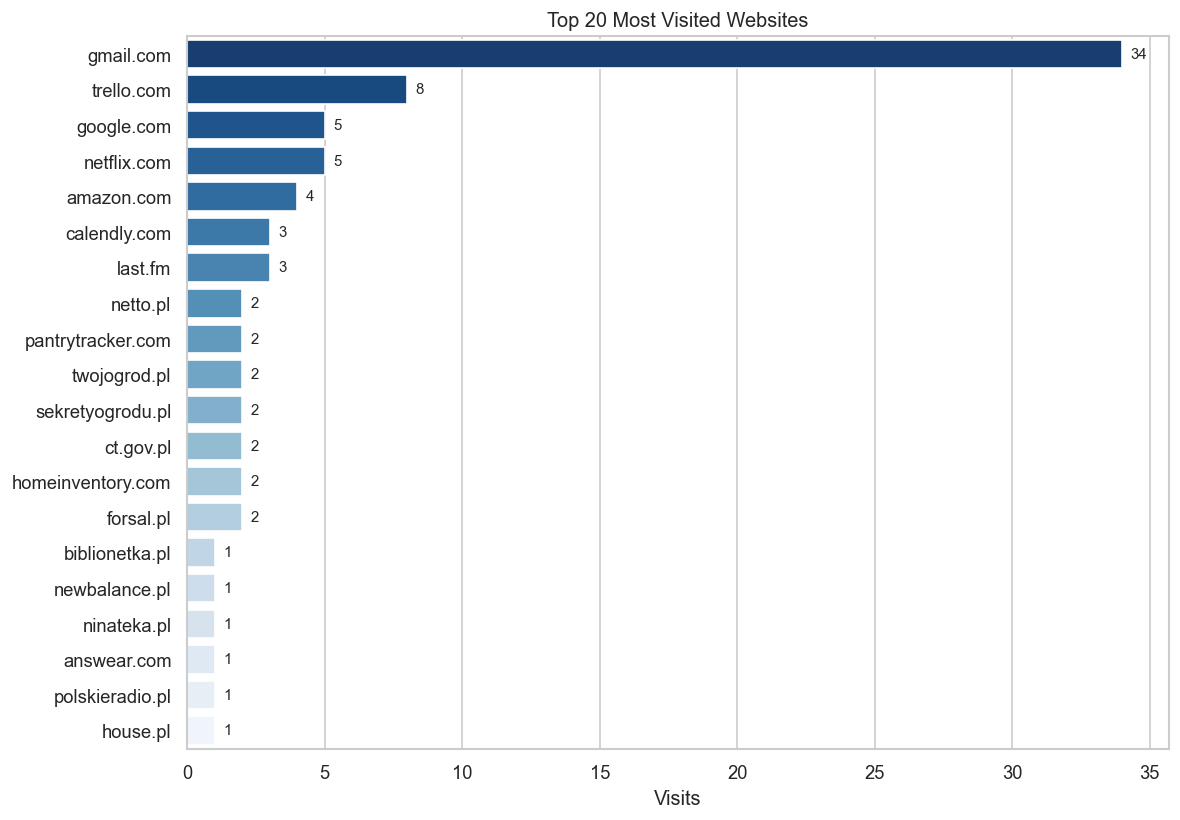

In [4]:
top20 = df["website"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index, ax=ax, palette="Blues_r")
ax.set_title("Top 20 Most Visited Websites")
ax.set_xlabel("Visits")
ax.set_ylabel("")
for i, v in enumerate(top20.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Visits by action type

/var/folders/69/y3nff79x2898z23682fhc2v80000gn/T/ipykernel_18674/1224436821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_action.index, y=by_action.values, ax=ax1, palette="Set2")


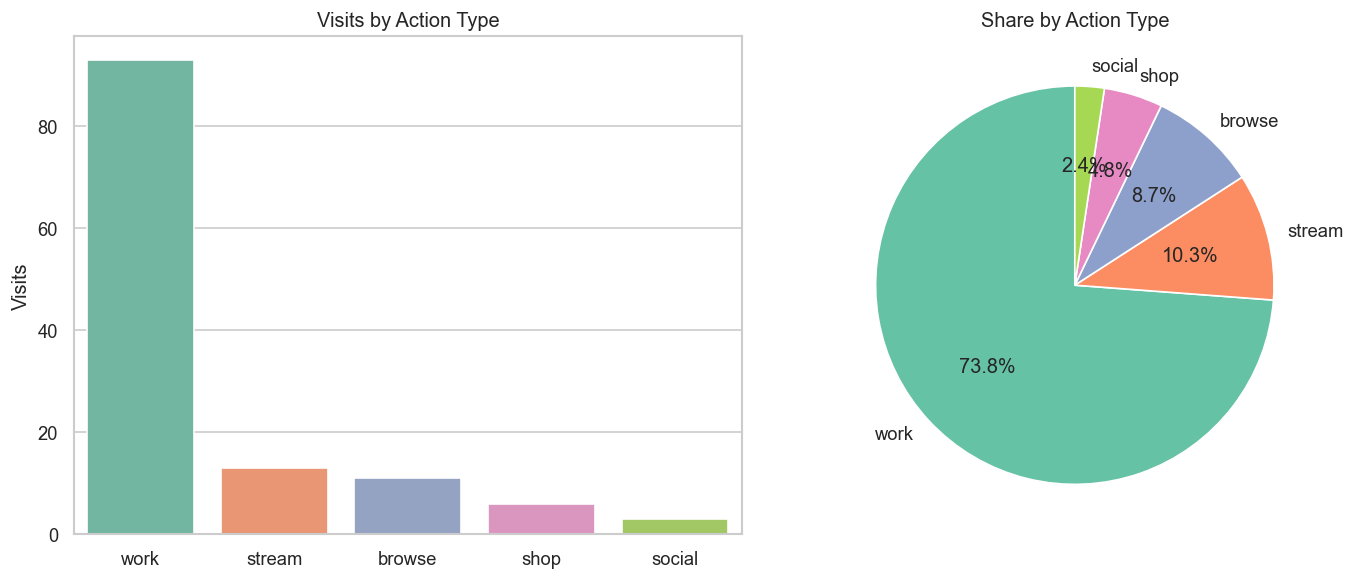

In [5]:
by_action = df["action_type"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar
sns.barplot(x=by_action.index, y=by_action.values, ax=ax1, palette="Set2")
ax1.set_title("Visits by Action Type")
ax1.set_xlabel("")
ax1.set_ylabel("Visits")

# Pie
ax2.pie(by_action.values, labels=by_action.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set2", len(by_action)))
ax2.set_title("Share by Action Type")

plt.tight_layout()
plt.show()

## Top 5 websites per action type

/var/folders/69/y3nff79x2898z23682fhc2v80000gn/T/ipykernel_18674/3702798195.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, ax=axes[i], palette="muted")
/var/folders/69/y3nff79x2898z23682fhc2v80000gn/T/ipykernel_18674/3702798195.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, ax=axes[i], palette="muted")
/var/folders/69/y3nff79x2898z23682fhc2v80000gn/T/ipykernel_18674/3702798195.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, ax=axes[i], pal

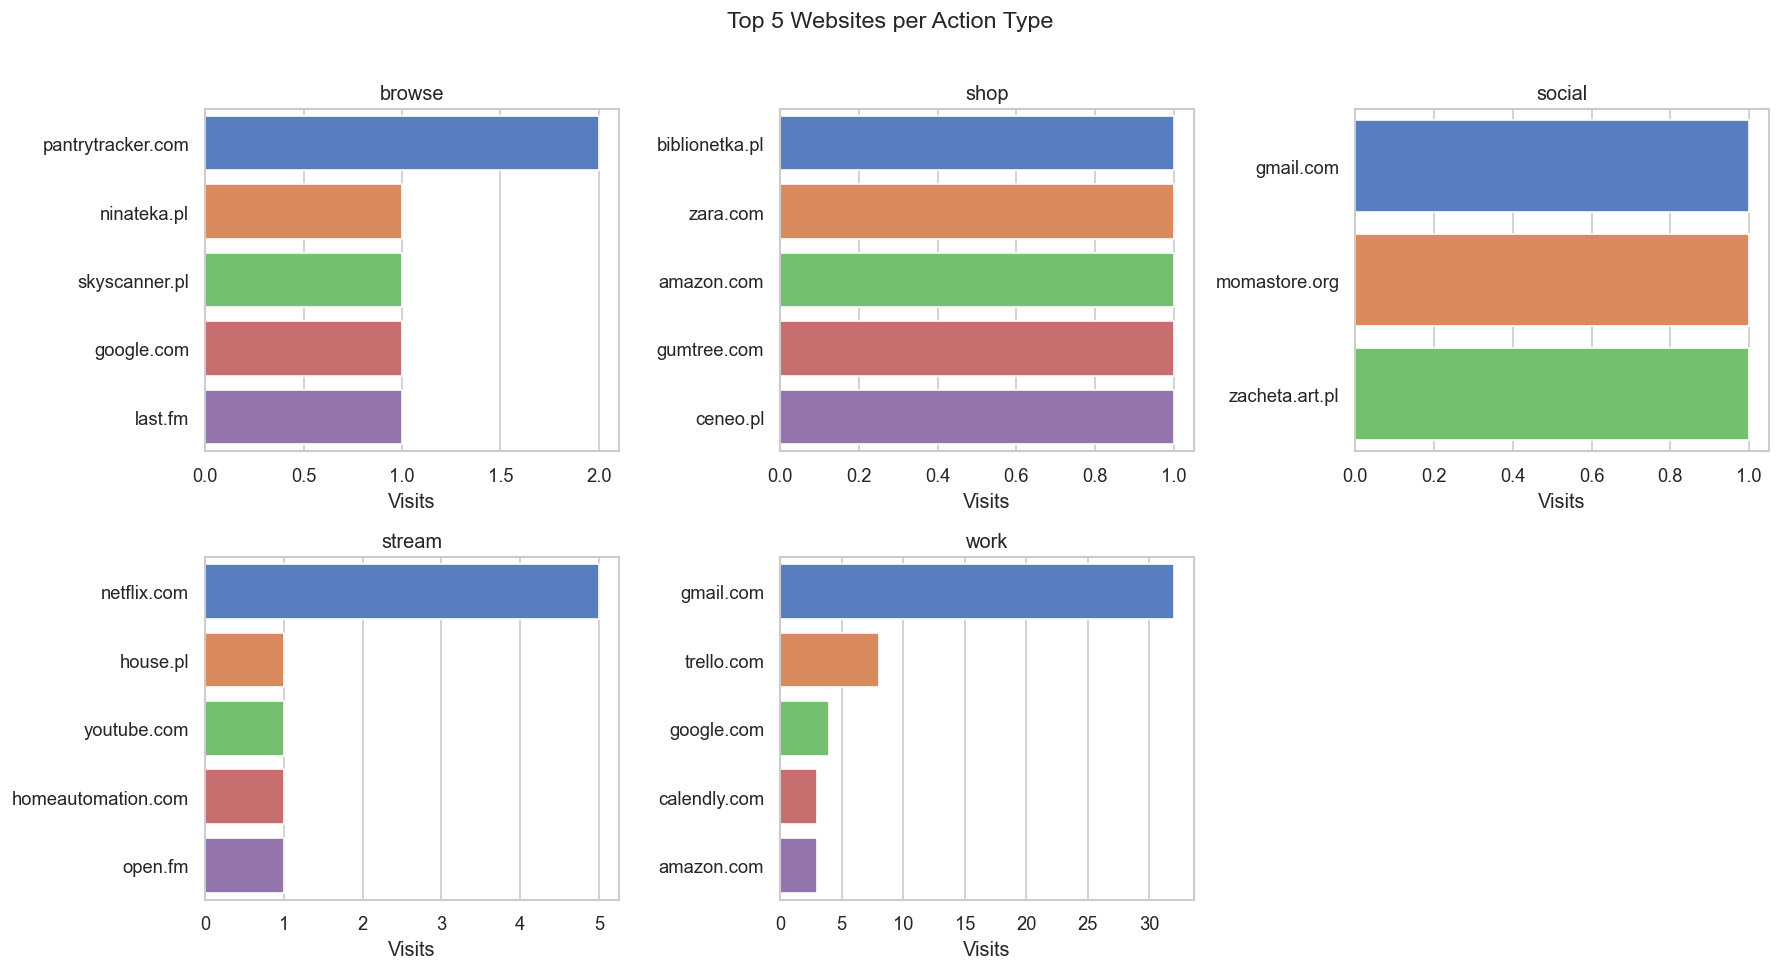

In [6]:
action_types = df["action_type"].dropna().unique()
n = len(action_types)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, at in enumerate(sorted(action_types)):
    top5 = df[df["action_type"] == at]["website"].value_counts().head(5)
    sns.barplot(x=top5.values, y=top5.index, ax=axes[i], palette="muted")
    axes[i].set_title(f"{at}")
    axes[i].set_xlabel("Visits")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Top 5 Websites per Action Type", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Visits over time

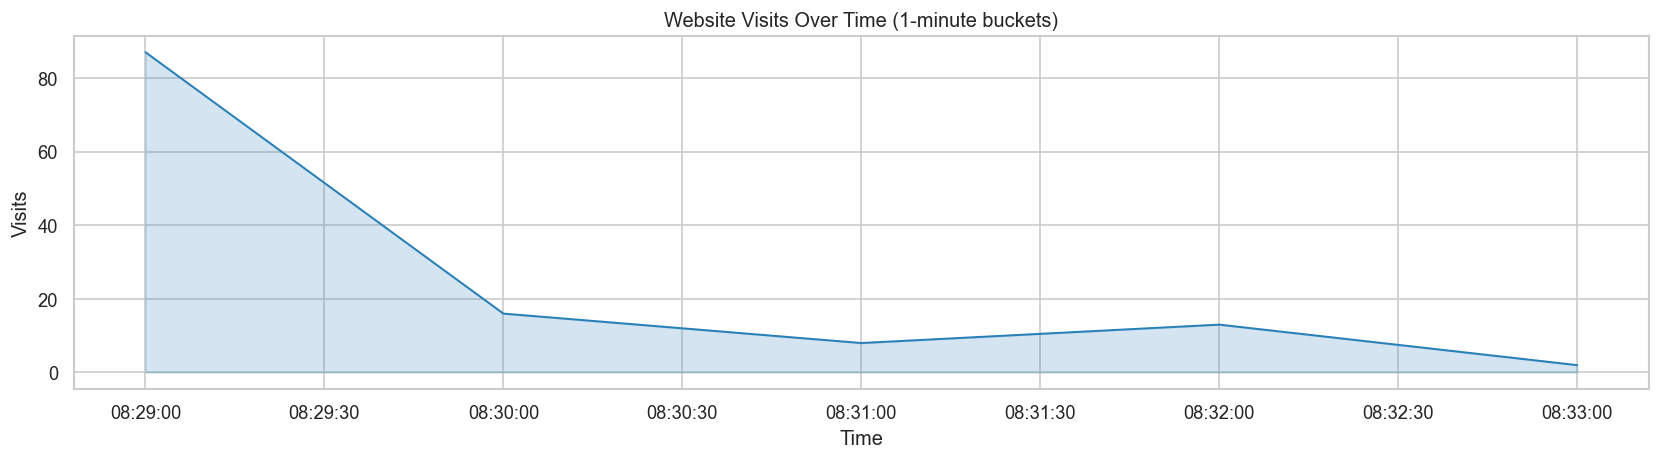

In [7]:
visits_over_time = df.set_index("timestamp").resample("1min")["website"].count()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(visits_over_time.index, visits_over_time.values, linewidth=1.2, color="#2980b9")
ax.fill_between(visits_over_time.index, visits_over_time.values, alpha=0.2, color="#2980b9")
ax.set_title("Website Visits Over Time (1-minute buckets)")
ax.set_xlabel("Time")
ax.set_ylabel("Visits")
plt.tight_layout()
plt.show()

## Device usage

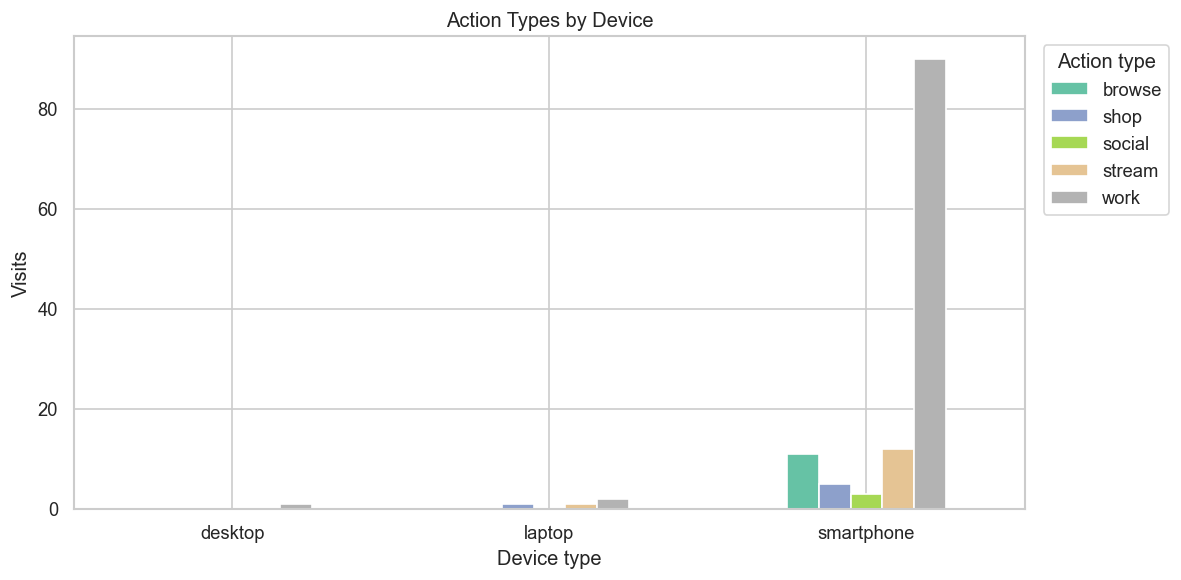

In [8]:
device_action = df.groupby(["device_type", "action_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
device_action.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("Action Types by Device")
ax.set_xlabel("Device type")
ax.set_ylabel("Visits")
ax.legend(title="Action type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()